In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sample = pd.read_csv('mid_project/sample_submission.csv')
df_test = pd.read_csv('mid_project/test.csv')
df_train = pd.read_csv('mid_project/train.csv')

### Загальна інформація про дані в наявних датасетах

In [3]:
print('Розмірність sample датасету:'
      f'\nРядків: {df_sample.shape[0]}'
     f'\nКолонок: {df_sample.shape[1]}')

Розмірність sample датасету:
Рядків: 48108
Колонок: 2


In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48108 entries, 0 to 48107
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         48108 non-null  int64  
 1   Predicted  48108 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 751.8 KB


In [5]:
df_sample.head()

,Id,Predicted
0,1,0.5
1,2,0.5
2,3,0.5
3,4,0.5
4,5,0.5


Колонка 'Predicted' буде замінена на отримані результати і завантажена в якості submission.  
Опис у завданні - 'a sample submission of loan default probability for each sample in the test set'.

### Розглянемо тренувальний датасет

The data for this competition consists of credit information about bank customers.  
Маємо датасет з кредитною історією клієнтів певного банку.

In [6]:
print('Розмірність train датасету:'
      f'\nРядків: {df_train.shape[0]}'
     f'\nКолонок: {df_train.shape[1]}')

Розмірність train датасету:
Рядків: 72161
Колонок: 12


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72161 entries, 0 to 72160
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Id                                                72161 non-null  int64  
 1   age                                               65017 non-null  float64
 2   number_dependent_family_members                   67945 non-null  float64
 3   monthly_income                                    66145 non-null  float64
 4   number_of_credit_lines                            66007 non-null  float64
 5   real_estate_loans                                 68355 non-null  float64
 6   ratio_debt_payment_to_income                      66553 non-null  float64
 7   credit_line_utilization                           65815 non-null  object 
 8   number_of_previous_late_payments_up_to_59_days    67966 non-null  float64
 9   number_of_previou

Маємо 72161 клієнта та 12 ознак (разом з ID та нашим таргетом).  
Тобто ознак з якими ми будемо працювати у нас 10.  
Також можна помітити відсутність даних, що більш детально розглянемо нижче.

In [8]:
df_train.head()

,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more,defaulted_on_loan
0,1,66.0,NaN,4000.0,NaN,1.0,0.569108,0.05488766900000001,0.0,0.0,0.0,0
1,2,61.0,2.0,4000.0,6.0,1.0,0.297176,0.10194991099999999,0.0,0.0,0.0,0
2,3,31.0,2.0,3040.0,8.0,0.0,0.160145,1.22713507,4.0,0.0,0.0,1
3,4,54.0,4.0,10218.0,5.0,0.0,0.067913,0.08327777900000001,0.0,0.0,0.0,0
4,5,29.0,0.0,4468.0,6.0,0.0,0.328261,0.317445504,0.0,0.0,0.0,0


**Id** - звичайний порядковий номер клієнта в системі банку.  
**defaulted_on_loan** - наш таргет. Дискретне значення, чи порушить клієнт умови кредиту протягом двох років (0, 1).  
**age** - вік клієнта.  
**number_dependent_family_members** - кількість залежних від клієнта членів родини.  
**monthly_income** - загальний дохід клієнта на місяць.  
**number_of_credit_lines** - загальна кількість займів та кредитних ліній (кредитних карток) відкритих клієнту.  
**real_estate_loans** - загальна кількість позик на нерухомість та кредитних ліній (іпотека).  
**ratio_debt_payment_to_income** - співвідношення щомісячних виплат по позикам до щомісячного доходу.  
**credit_line_utilization** - баланс по кредитних лініях та позиках, поділений на суму кредитних лімітів.  
**number_of_previous_late_payments_up_to_59_days** - кількість разів коли клієнт запізнився з виплатами по займам, але не пізніше 59 доби.  
**number_of_previous_late_payments_up_to_89_days** - кількість разів коли клієнт запізнився з виплатами по займам, між 60 та 89 добами.  
**number_of_previous_late_payments_90_days_or_more** - кількість разів коли клієнт запізнився з виплатами по займам, мініму на 90 днів і більше.  

Маємо велику проблему з ознакою 'credit_line_utilization'.  
Тип даних відображається як object, але ми бачимо числа з плаваючою комою.  
Тобто дані там можуть бути будь-якого типу, наприклад str.  
Ця ознака характеризує кредитне навантаження.  
Наскільки активно наш клієнт лізе в борги, його фінансова грамотність.  
Ця ознака має сильно впливати на остаточне рішення по вірогідності дефолту.  
Перед навчанням моделі має бути обов'язково детально розглянута.

Розглянемо таргет.

In [9]:
target_list = df_train['defaulted_on_loan'].value_counts()
target_list

defaulted_on_loan
0    67148
1     5013
Name: count, dtype: int64

Маємо розбалансований таргет. Неплатників набагато менше, що добре для банку.

In [10]:
imbalance = target_list[0] / target_list[1]
print(f'Співвідношення платників до неплатників: {imbalance:.1f}')

Співвідношення платників до неплатників: 13.4


In [11]:
print(f'Не дефолт (у відсотках) : {target_list[0] / df_train.shape[0]:.2%}'
      f'\nДефолт (у відсотках) : {target_list[1] / df_train.shape[0]:.2%}')

Не дефолт (у відсотках) : 93.05%
Дефолт (у відсотках) : 6.95%


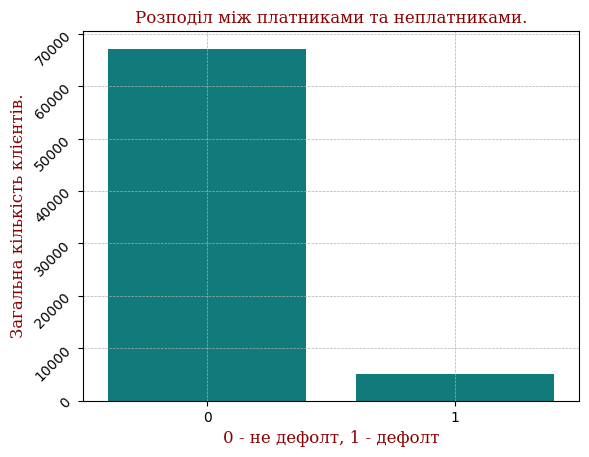

In [12]:
sns.barplot(target_list, color='DarkCyan')

myfont = {'family':'serif','color':'darkred','size':12}

plt.title('Розподіл між платниками та неплатниками.', fontdict=myfont)
plt.yticks(rotation=45, ha="right")
plt.xlabel('0 - не дефолт, 1 - дефолт', fontdict=myfont)
plt.ylabel('Загальна кількість клієнтів.', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)
plt.show()

Розглянемо NaN значення у тренувальному датасеті.

In [13]:
df_train_copy = df_train.copy()

In [14]:
is_nan = df_train_copy.isna().sum()
is_nan

Id                                                     0
age                                                 7144
number_dependent_family_members                     4216
monthly_income                                      6016
number_of_credit_lines                              6154
real_estate_loans                                   3806
ratio_debt_payment_to_income                        5608
credit_line_utilization                             6346
number_of_previous_late_payments_up_to_59_days      4195
number_of_previous_late_payments_up_to_89_days      5845
number_of_previous_late_payments_90_days_or_more    3621
defaulted_on_loan                                      0
dtype: int64

In [15]:
is_nan_percent = (is_nan / df_train_copy.shape[0]) * 100
is_nan_percent

Id                                                  0.000000
age                                                 9.900085
number_dependent_family_members                     5.842491
monthly_income                                      8.336913
number_of_credit_lines                              8.528152
real_estate_loans                                   5.274317
ratio_debt_payment_to_income                        7.771511
credit_line_utilization                             8.794224
number_of_previous_late_payments_up_to_59_days      5.813390
number_of_previous_late_payments_up_to_89_days      8.099943
number_of_previous_late_payments_90_days_or_more    5.017946
defaulted_on_loan                                   0.000000
dtype: float64

Маємо від 5% до 10% відсутньої інформації, що є невисоким показником. 

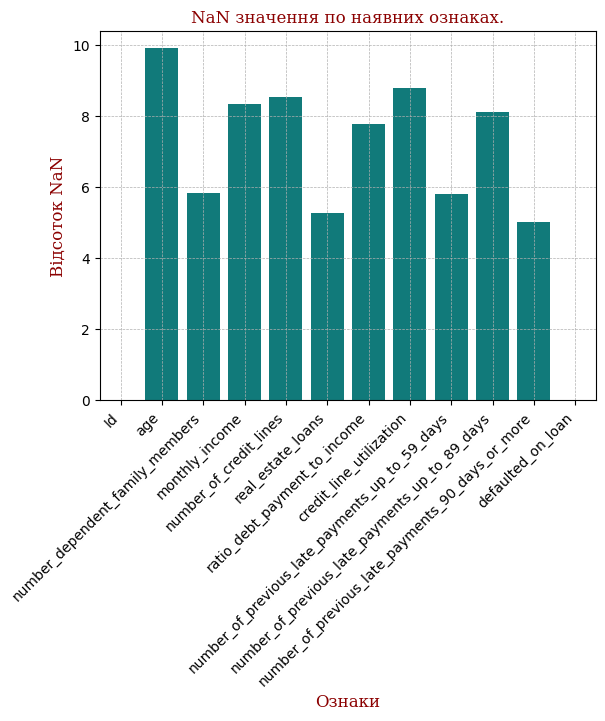

In [16]:
sns.barplot(is_nan_percent, color='DarkCyan')

myfont = {'family':'serif','color':'darkred','size':12}

plt.title('NaN значення по наявних ознаках.', fontdict=myfont)
plt.xticks(rotation=45, ha="right")
plt.xlabel('Ознаки', fontdict=myfont)
plt.ylabel('Відсоток NaN', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)
plt.show()

Розглянемо якість наших даних.

Виправимо нашу ознаку 'credit_line_utilization'.  
Зведемо усі розділові знаки до крапок, та змінимо тип даних. 

In [17]:
df_train_copy['credit_line_utilization'] = df_train_copy['credit_line_utilization'].str.replace(',', '.')
df_train_copy['credit_line_utilization_new'] = pd.to_numeric(df_train_copy['credit_line_utilization'], errors='coerce')

In [18]:
df_train_copy['credit_line_utilization'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 72161 entries, 0 to 72160
Series name: credit_line_utilization
Non-Null Count  Dtype 
--------------  ----- 
65815 non-null  object
dtypes: object(1)
memory usage: 563.9+ KB


In [19]:
df_train_copy['credit_line_utilization_new'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 72161 entries, 0 to 72160
Series name: credit_line_utilization_new
Non-Null Count  Dtype  
--------------  -----  
65815 non-null  float64
dtypes: float64(1)
memory usage: 563.9 KB


In [20]:
print(f'Кількість NaN на початку: {df_train_copy['credit_line_utilization'].isna().sum()}'
      f'\nКількість NaN після зміни типу даних: {df_train_copy['credit_line_utilization_new'].isna().sum()}')

Кількість NaN на початку: 6346
Кількість NaN після зміни типу даних: 6346


Маємо необхідний результат. Тип даних тепер float і кількість NaN значень відповідна.  
Можна прибрати зайву колонку, оскільки ми працюємо з копією датасету.

In [21]:
df_train_copy['credit_line_utilization'] = df_train_copy['credit_line_utilization_new']

In [22]:
df_train_copy = df_train_copy.drop('credit_line_utilization_new', axis=1)
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72161 entries, 0 to 72160
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Id                                                72161 non-null  int64  
 1   age                                               65017 non-null  float64
 2   number_dependent_family_members                   67945 non-null  float64
 3   monthly_income                                    66145 non-null  float64
 4   number_of_credit_lines                            66007 non-null  float64
 5   real_estate_loans                                 68355 non-null  float64
 6   ratio_debt_payment_to_income                      66553 non-null  float64
 7   credit_line_utilization                           65815 non-null  float64
 8   number_of_previous_late_payments_up_to_59_days    67966 non-null  float64
 9   number_of_previou

In [23]:
df_train_copy.describe()

,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more,defaulted_on_loan
count,72161.000000,65017.000000,67945.000000,6.614500e+04,66007.000000,68355.000000,66553.000000,65815.000000,67966.000000,66316.000000,68540.000000,72161.000000
mean,36081.000000,51.388914,0.847009,6.624388e+03,8.756193,1.050296,26.524005,5.225040,0.393491,0.206074,0.224059,0.069470
std,20831.230725,14.414338,1.144038,1.084630e+04,5.198769,1.114420,399.253008,212.152963,3.680686,3.696260,3.634436,0.254253
min,1.000000,21.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18041.000000,41.000000,0.000000,3.400000e+03,5.000000,0.000000,0.141302,0.035123,0.000000,0.000000,0.000000,0.000000
50%,36081.000000,51.000000,0.000000,5.400000e+03,8.000000,1.000000,0.294673,0.176500,0.000000,0.000000,0.000000,0.000000
75%,54121.000000,62.000000,2.000000,8.232000e+03,11.000000,2.000000,0.480989,0.578536,0.000000,0.000000,0.000000,0.000000
max,72161.000000,103.000000,13.000000,1.560100e+06,57.000000,25.000000,61106.500000,29110.000000,98.000000,98.000000,98.000000,1.000000


Бачимо цікаві викиди по нашим ознакам. 57 кредитних ліній, 25 займів під нерухомість, по 98 пізніх виплат на різні терміни.  
Можливо мали місце проблеми конвертації даних при завантажені файла csv.  
Бо ми бачимо аномально великі значення там, де діапазон має бути від 0 до 1 (ratio_debt_payment_to_income та credit_line_utilization_new).

Подивимось на ці дані з викидами.

C:\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


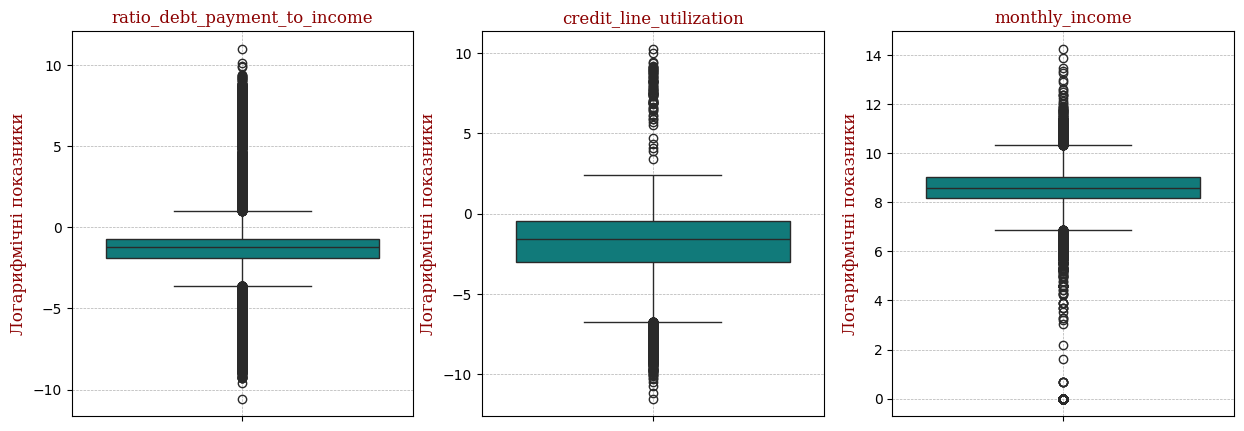

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=np.log(df_train_copy["ratio_debt_payment_to_income"]), color='DarkCyan')
plt.title('ratio_debt_payment_to_income', fontdict=myfont)
plt.ylabel('Логарифмічні показники', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.subplot(1, 3, 2)
sns.boxplot(y=np.log(df_train_copy["credit_line_utilization"]), color='DarkCyan')
plt.title('credit_line_utilization', fontdict=myfont)
plt.ylabel('Логарифмічні показники', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.subplot(1, 3, 3)
sns.boxplot(y=np.log(df_train_copy["monthly_income"]), color='DarkCyan')
plt.title('monthly_income', fontdict=myfont)
plt.ylabel('Логарифмічні показники', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.show()

Спробуємо таку стратегію.  
Для наших показників credit_line_utilization та ratio_debt_payment_to_income застосуємо ліміт.  
Оскільки ці показники мають бути в межах від 0 до 1, то будь-які великі значення це вже ризик для банку.  
І не важливо буде це 10 або 10000.

In [25]:
df_train_copy['credit_line_utilization'] = df_train_copy['credit_line_utilization'].clip(upper=1.5)
df_train_copy['ratio_debt_payment_to_income'] = df_train_copy['ratio_debt_payment_to_income'].clip(upper=1.5)

In [26]:
df_train_copy['credit_line_utilization'] = df_train_copy['credit_line_utilization'].fillna(df_train_copy['credit_line_utilization'].median())
df_train_copy['ratio_debt_payment_to_income'] = df_train_copy['ratio_debt_payment_to_income'].fillna(df_train_copy['ratio_debt_payment_to_income'].median())

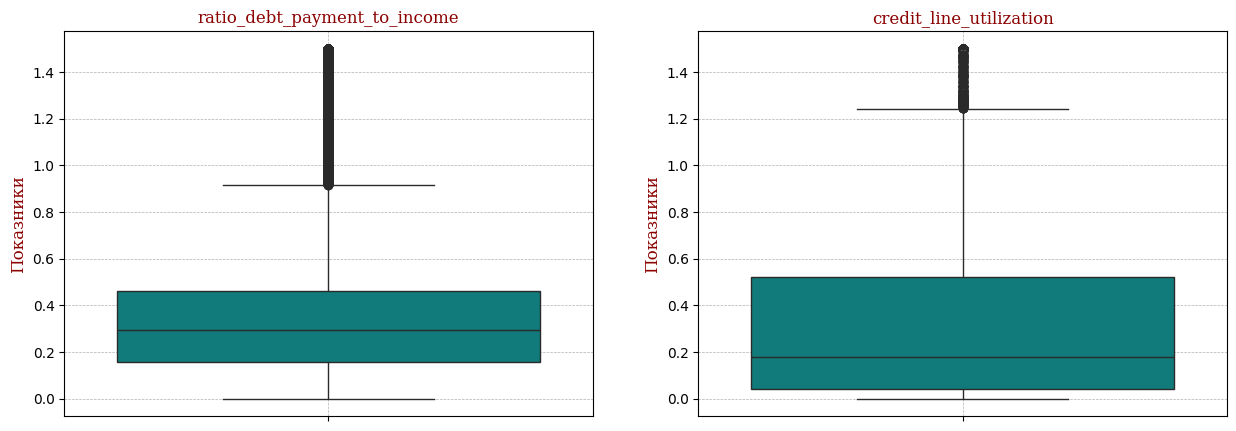

In [27]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_train_copy["ratio_debt_payment_to_income"], color='DarkCyan')
plt.title('ratio_debt_payment_to_income', fontdict=myfont)
plt.ylabel('Показники', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_train_copy["credit_line_utilization"], color='DarkCyan')
plt.title('credit_line_utilization', fontdict=myfont)
plt.ylabel('Показники', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.show()

Маємо покращену картину. Тепер аномальні викиди не будуть заважати моделі.

Для боротьби з викидами у 'monthly_income' скористаємось наступною стратегією.  
Нульові значення будуть замінені на медіану.  
Потім колонка пройде логарифмування.

In [28]:
df_train_copy['monthly_income'].value_counts().iloc[:20].sort_index(ascending=True)

monthly_income
0.0         864
1.0         342
2000.0      604
2500.0      852
3000.0      985
3500.0      765
4000.0     1115
4200.0      320
4500.0      657
5000.0     1546
5500.0      494
6000.0     1064
6250.0      326
6500.0      470
7000.0      666
7500.0      556
8000.0      609
9000.0      407
10000.0     780
10500.0     587
Name: count, dtype: int64

Маємо одинички і нулики - буде заміна на медіану.

In [29]:
df_train_copy['monthly_income'] = df_train_copy['monthly_income'].replace([0, 1], df_train_copy['monthly_income'].median()).fillna(df_train_copy['monthly_income'].median())

In [30]:
upper_limit = df_train_copy['monthly_income'].quantile(0.99)
df_train_copy['monthly_income'] = df_train_copy['monthly_income'].clip(upper=upper_limit)

In [31]:
df_train_copy['monthly_income'] = np.log1p(df_train_copy['monthly_income'])

In [32]:
df_train_copy['monthly_income'].describe()

count    72161.000000
mean         8.563982
std          0.656685
min          1.098612
25%          8.228978
50%          8.594339
75%          8.978534
max         10.106469
Name: monthly_income, dtype: float64

Пропрацюємо усі NaN значення, і замінемо більш логічними параметрами.  
'Age' - медіаною.  
'number_dependent_family_members' - вирішила взяти моду.  
'monthly_income' - медіаною.  
'number_of_credit_lines' - 0,  
'real_estate_loans' - 0,  
'number_of_previous_late_payments_up_to_59_days' - 0,  
'number_of_previous_late_payments_up_to_89_days' - 0,  
'number_of_previous_late_payments_90_days_or_more' - 0,  
'ratio_debt_payment_to_income' - медіана,  
'credit_line_utilization' - медіана.

In [33]:
family_mode = df_train_copy['number_dependent_family_members'].mode()[0]

In [34]:
df_train_copy['number_dependent_family_members'] = df_train_copy['number_dependent_family_members'].fillna(family_mode)

In [35]:
df_train_copy['age'] = df_train_copy['age'].fillna(df_train_copy['age'].median())

In [36]:
fill_NaN = [
    'number_of_credit_lines',
    'real_estate_loans',
    'number_of_previous_late_payments_up_to_59_days',
    'number_of_previous_late_payments_up_to_89_days',
    'number_of_previous_late_payments_90_days_or_more'
]

In [37]:
df_train_copy[fill_NaN] = df_train_copy[fill_NaN].fillna(0)

In [38]:
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72161 entries, 0 to 72160
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Id                                                72161 non-null  int64  
 1   age                                               72161 non-null  float64
 2   number_dependent_family_members                   72161 non-null  float64
 3   monthly_income                                    72161 non-null  float64
 4   number_of_credit_lines                            72161 non-null  float64
 5   real_estate_loans                                 72161 non-null  float64
 6   ratio_debt_payment_to_income                      72161 non-null  float64
 7   credit_line_utilization                           72161 non-null  float64
 8   number_of_previous_late_payments_up_to_59_days    72161 non-null  float64
 9   number_of_previou

Потрібно ще подивитися цікаві "викиди" по наступним ознакам:  
number_of_credit_lines  
real_estate_loans  
number_dependent_family_members  
number_of_previous_late_payments_up_to_59_days  
number_of_previous_late_payments_up_to_89_days  
number_of_previous_late_payments_90_days_or_more  

In [39]:
df_train_copy.head()

,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more,defaulted_on_loan
0,1,66.0,0.0,8.294300,0.0,1.0,0.569108,0.054888,0.0,0.0,0.0,0
1,2,61.0,2.0,8.294300,6.0,1.0,0.297176,0.101950,0.0,0.0,0.0,0
2,3,31.0,2.0,8.019942,8.0,0.0,0.160145,1.227135,4.0,0.0,0.0,1
3,4,54.0,4.0,9.232004,5.0,0.0,0.067913,0.083278,0.0,0.0,0.0,0
4,5,29.0,0.0,8.404920,6.0,0.0,0.328261,0.317446,0.0,0.0,0.0,0


Зведемо наші дискретні ознаки до типу int, щоб мати більш охайний формат.

In [40]:
to_int = [
    'age',
    'number_dependent_family_members',
    'real_estate_loans',
    'number_of_credit_lines',
    'number_of_previous_late_payments_up_to_59_days',
    'number_of_previous_late_payments_up_to_89_days',
    'number_of_previous_late_payments_90_days_or_more'
]

In [41]:
df_train_copy[to_int] = df_train_copy[to_int].astype(int)

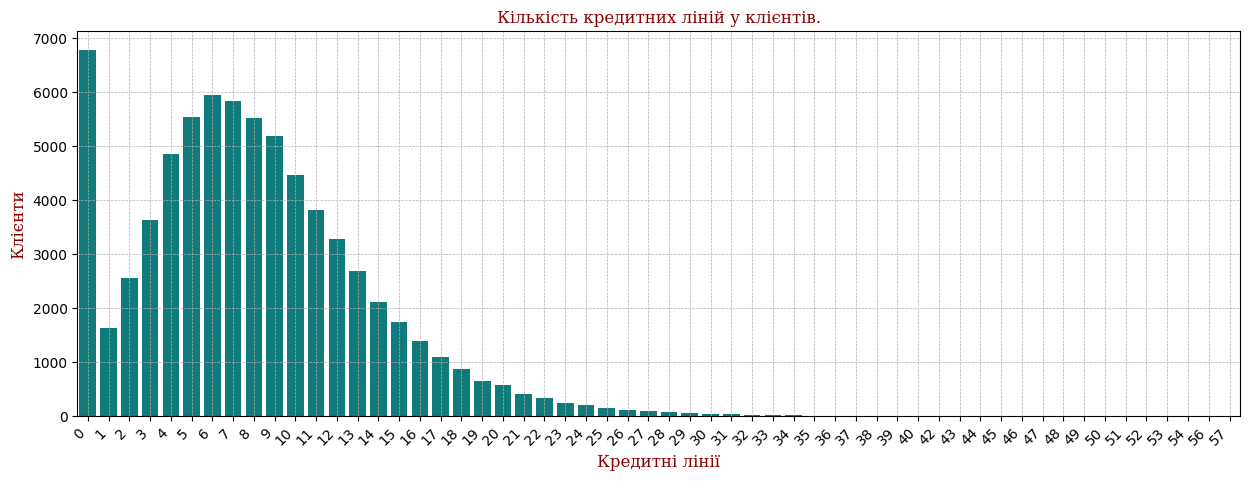

In [42]:
plt.figure(figsize=(15, 5))

sns.countplot(data=df_train_copy, x='number_of_credit_lines', color='DarkCyan')
 
plt.title('Кількість кредитних ліній у клієнтів.', fontdict=myfont)
plt.xticks(rotation=45, ha="right")
plt.xlabel('Кредитні лінії', fontdict=myfont)
plt.ylabel('Клієнти', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.show()

Цікаво подивитися залежність між кількістю карток і можливістю дефолту.

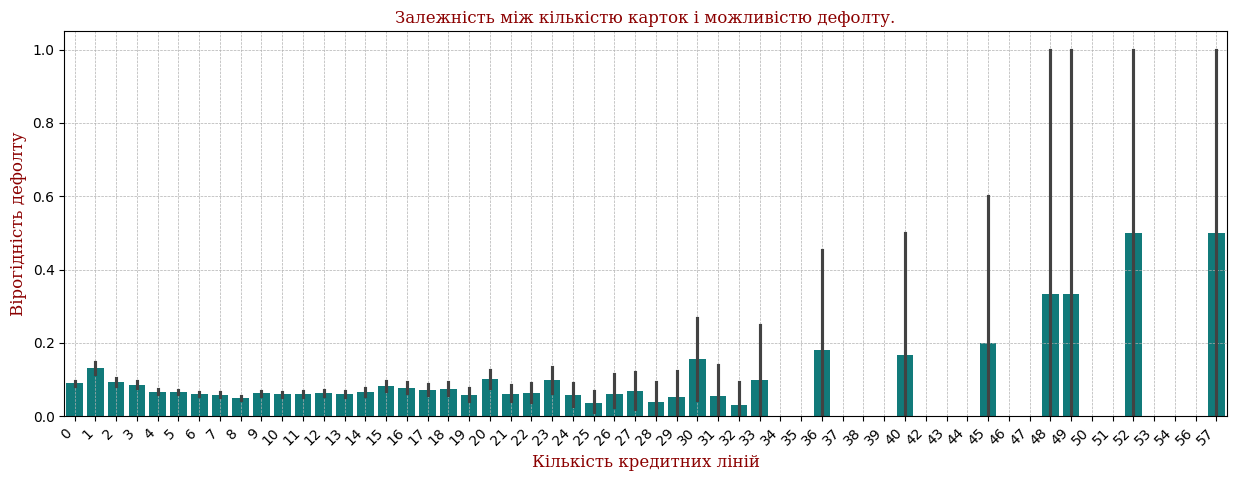

In [43]:
plt.figure(figsize=(15, 5))

sns.barplot(df_train_copy, x="number_of_credit_lines", y="defaulted_on_loan", color='DarkCyan')

plt.title('Залежність між кількістю карток і можливістю дефолту.', fontdict=myfont)
plt.xticks(rotation=45, ha="right")
plt.xlabel('Кількість кредитних ліній', fontdict=myfont)
plt.ylabel('Вірогідність дефолту', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.show()

Подивимось ближе категорію клієнтів, що мають 33 кредитні лінії.

In [44]:
df_train_copy[df_train_copy['number_of_credit_lines'] == 33]

,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more,defaulted_on_loan
2028,2029,69,0,8.594339,33,1,1.453564,0.102254,0,0,0,0
4888,4889,78,0,9.259226,33,0,0.096277,0.064620,0,0,0,0
10045,10046,57,0,9.259226,33,2,0.112275,0.176500,0,0,0,0
12845,12846,61,1,9.239996,33,2,0.211824,0.176500,0,0,0,0
15107,15108,58,0,9.548026,33,3,0.645288,0.573475,0,0,0,1
15587,15588,63,0,8.594339,33,1,0.306637,0.001067,0,0,0,0
21741,21742,47,0,8.374246,33,2,1.020766,0.045663,0,0,0,0
25079,25080,66,0,8.734721,33,1,0.432985,0.123077,1,0,0,0
28256,28257,56,0,8.572439,33,1,0.488456,0.089804,0,0,0,0
29235,29236,65,1,10.106469,33,3,0.092043,0.416126,0,0,1,0


Існує теорія, що чим більше у людини кредитних карток, тим більше в неї фінансових проблем.  
Частково, ця теорія підтверджується верхнім графіком.  
Але, при більш детальному розгляді клієнтів з 33 кредитними лініями, ми бачимо, що це клієнти з гарним доходом, з маленькими родинами або взагалі без родини, і вони майже не спізнюються з виплатами. Тобто, це можуть бути приватні підприємці, яким дійсно потрібно мати кілька кредитних ліній для ведення бізнесу. І це не значить, що вони у групі ризику.  

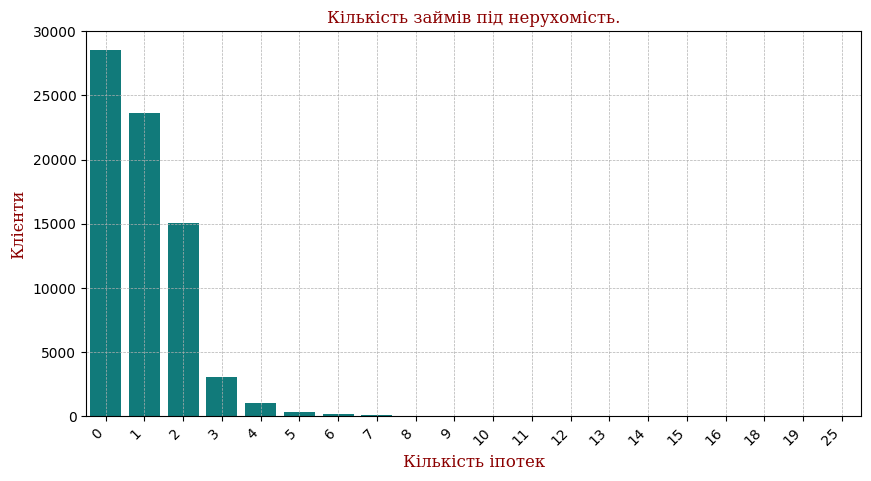

In [45]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_train_copy, x='real_estate_loans', color='DarkCyan')
 
plt.title('Кількість займів під нерухомість.', fontdict=myfont)
plt.xticks(rotation=45, ha="right")
plt.xlabel('Кількість іпотек', fontdict=myfont)
plt.ylabel('Клієнти', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.show()

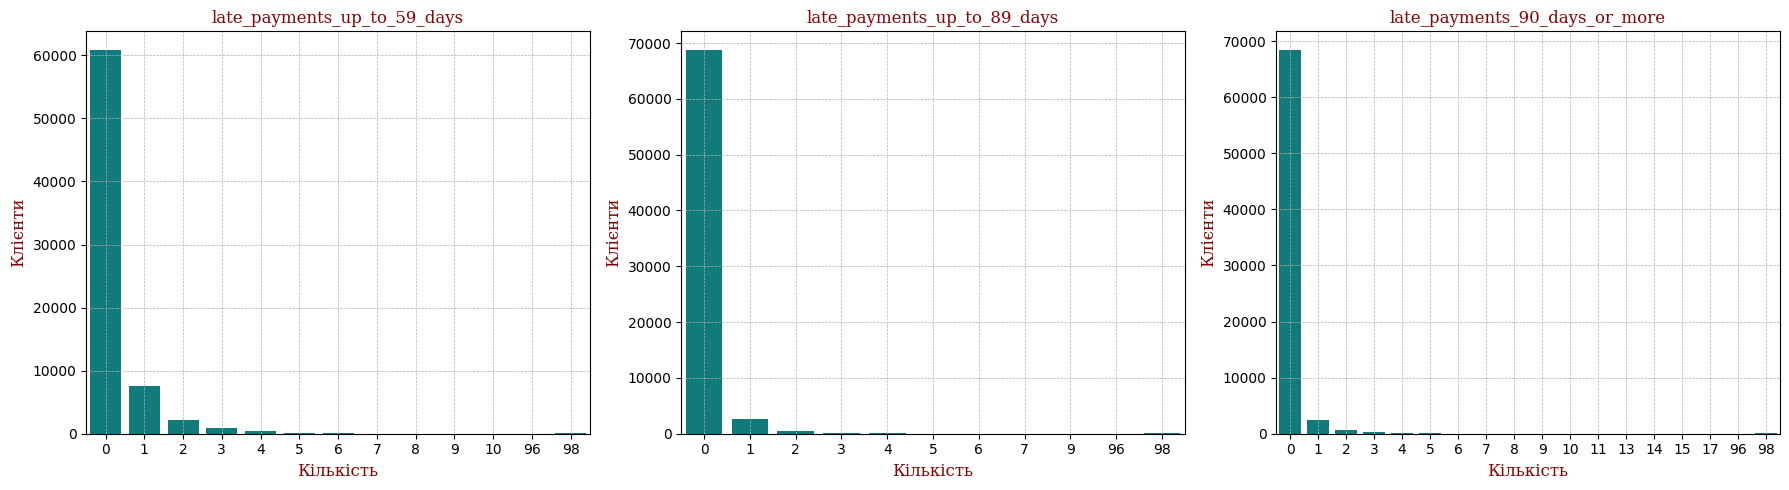

In [46]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df_train_copy, x='number_of_previous_late_payments_up_to_59_days', color='DarkCyan')
plt.title('late_payments_up_to_59_days', fontdict=myfont)
plt.xlabel('Кількість', fontdict=myfont)
plt.ylabel('Клієнти', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.subplot(1, 3, 2)
sns.countplot(data=df_train_copy, x='number_of_previous_late_payments_up_to_89_days', color='DarkCyan')
plt.title('late_payments_up_to_89_days', fontdict=myfont)
plt.xlabel('Кількість', fontdict=myfont)
plt.ylabel('Клієнти', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.subplot(1, 3, 3)
sns.countplot(data=df_train_copy, x='number_of_previous_late_payments_90_days_or_more', color='DarkCyan')
plt.title('late_payments_90_days_or_more', fontdict=myfont)
plt.xlabel('Кількість', fontdict=myfont)
plt.ylabel('Клієнти', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)

plt.tight_layout()
plt.show()

На даному етапі, розглянуті ознаки лишаться без змін, оскільки моделі, які будуть використані в подальшому навчанні (xgboost, lgboost),  
мають гарно працювати з викидами і впораються з кількома такими клієнтами. Можливо, такі клієнти будуть цікавими під час навчання моделі.

Маємо тепер датасет який фактично пройшов Preprocessing і готовий до роботи з моделями.

Перевіримо кореляції ознак.

In [47]:
df_train_copy = df_train_copy.drop('Id', axis=1)

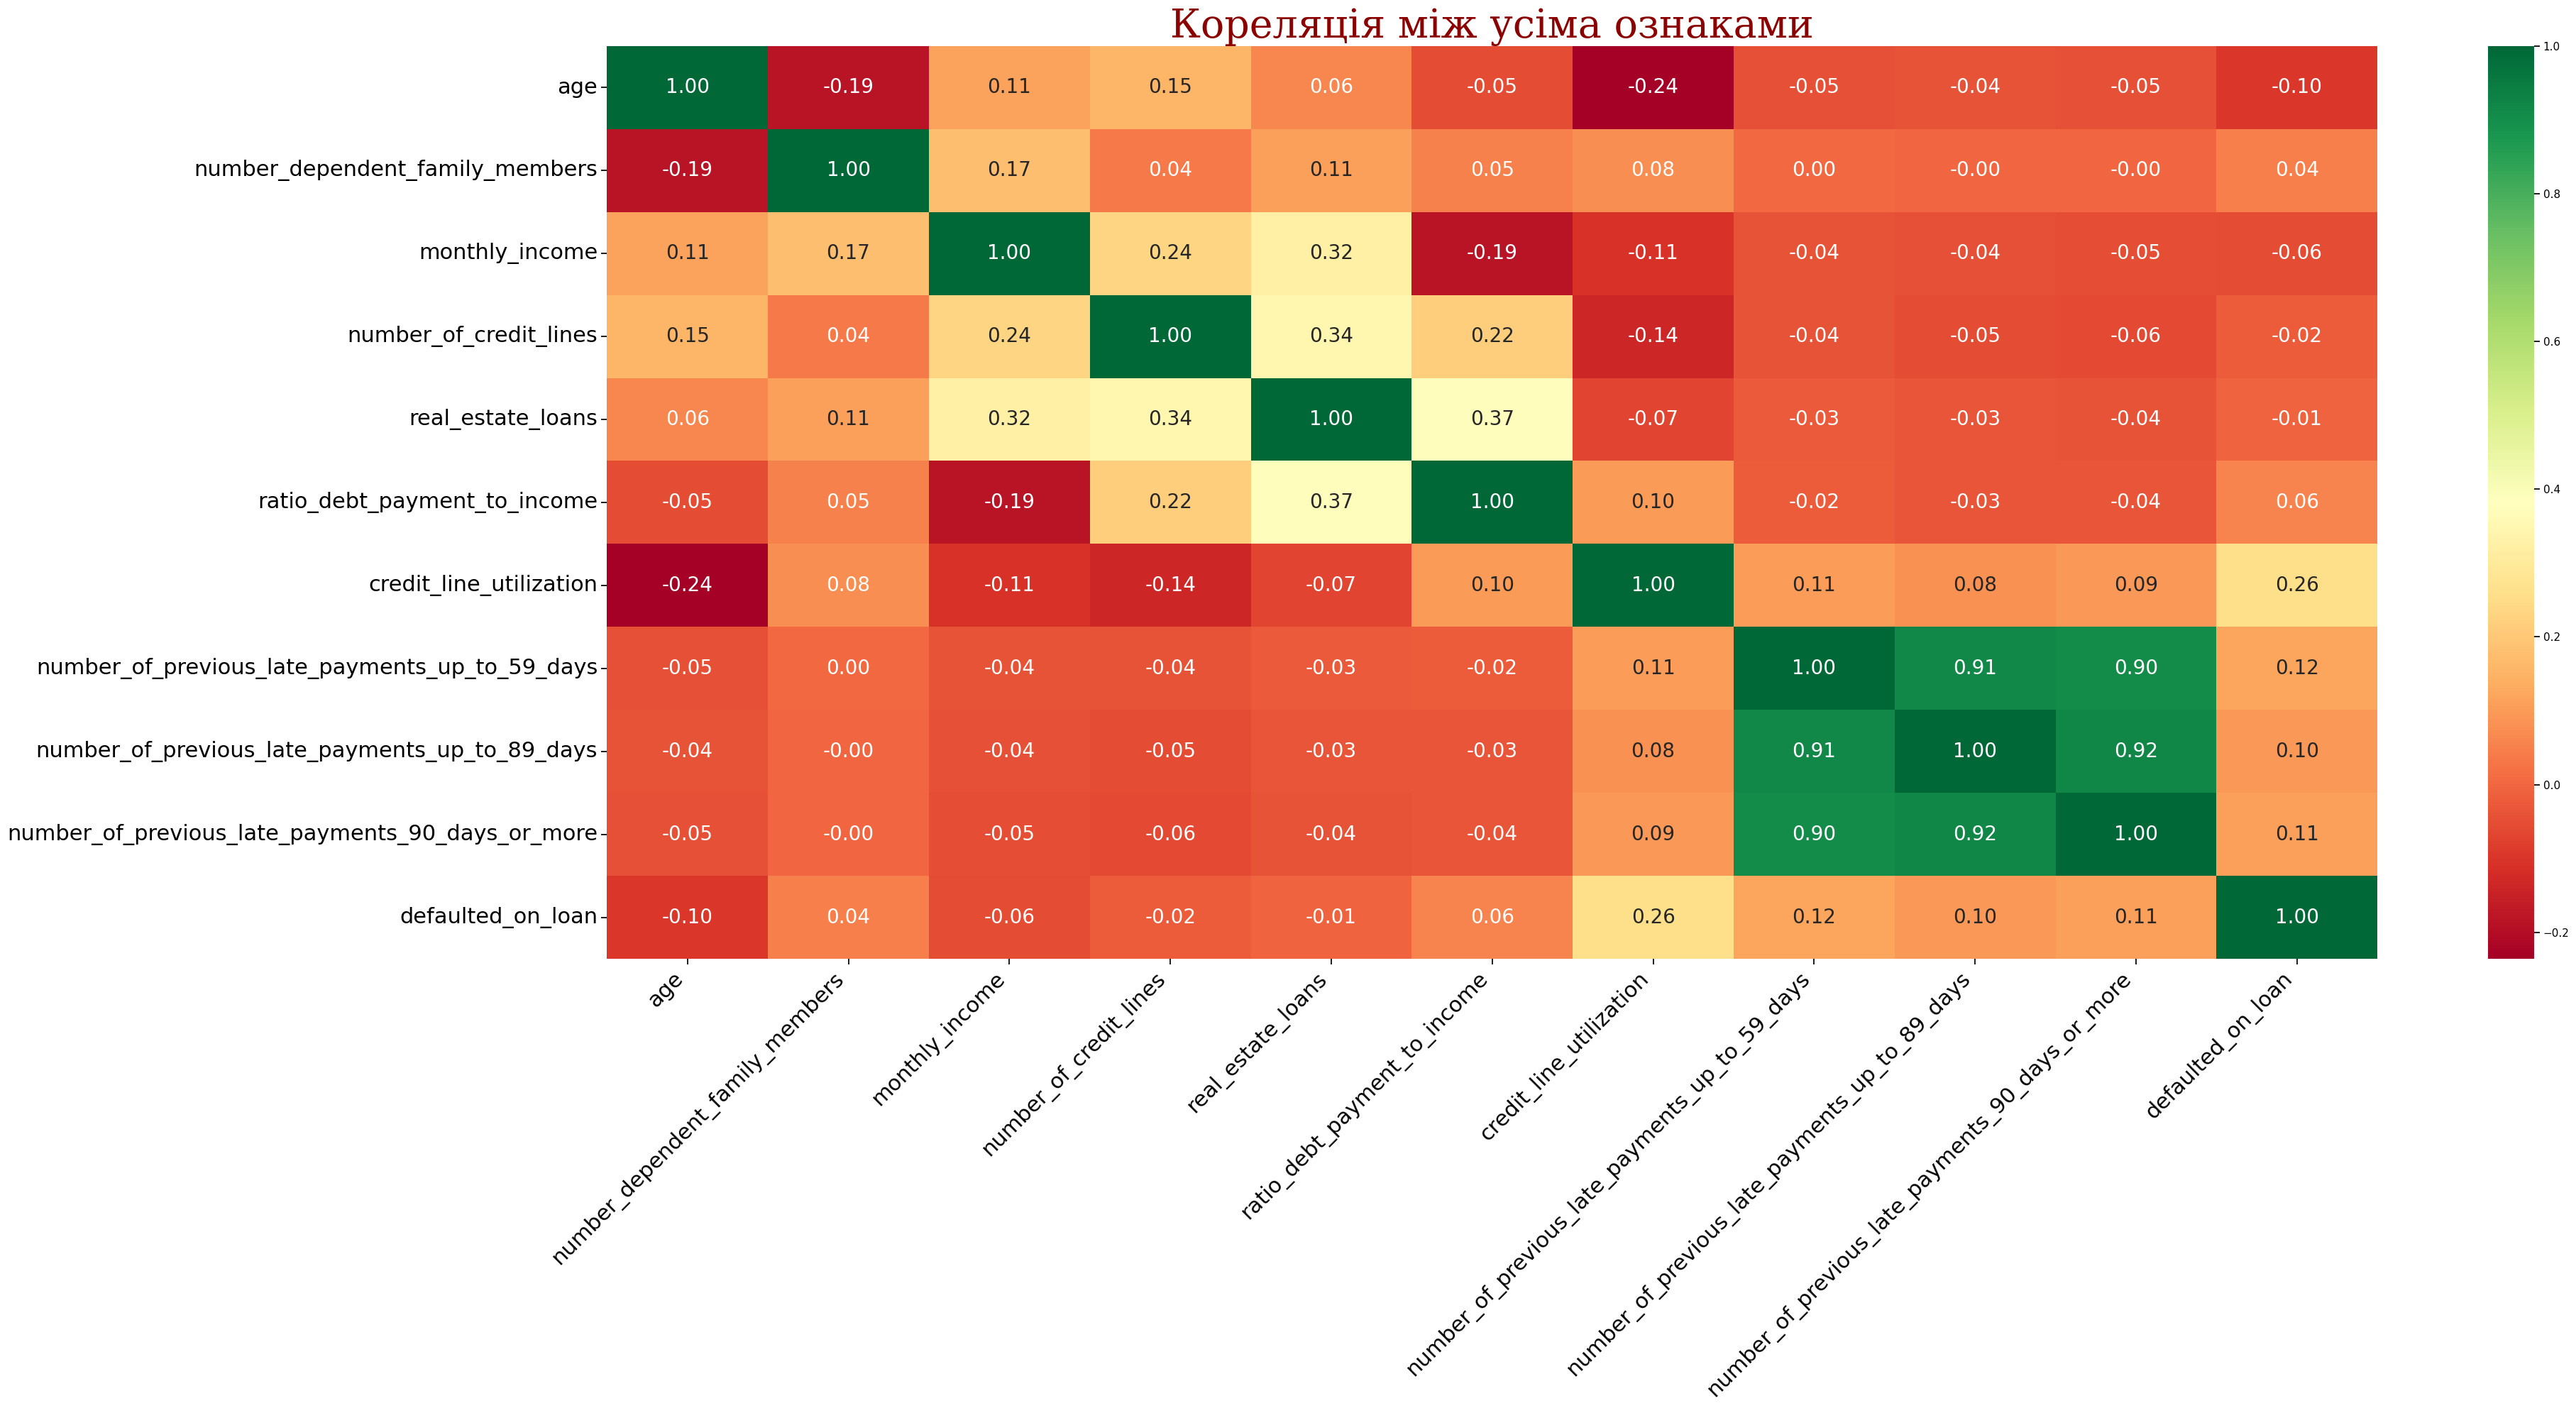

In [48]:
corr_matrix = df_train_copy.corr()
plt.figure(figsize=(40, 20))
sns.set_context("notebook", rc={"axes.labelsize": 25})
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', annot_kws={"size": 20}, fmt='.2f')

plt.title('Кореляція між усіма ознаками', fontdict=myfont, fontsize=40)

plt.xticks(rotation=45, ha="right", fontsize=22)
plt.yticks(rotation=0, fontsize=22)

plt.tight_layout()
plt.show()

Маємо мультиколінеарність по цим трьом ознакам:  
'number_of_previous_late_payments_up_to_59_days'  
'number_of_previous_late_payments_up_to_89_days'  
'number_of_previous_late_payments_90_days_or_more'  
Можна було б лишити тільки одну 'number_of_previous_late_payments_up_to_59_days' оскільки вона має найвищу кореляцію з таргетом.  
Але спробуємо створити додаткову колонку 'total_late_payments' де залишимо суму усіх трьох колонок.

In [49]:
df_train_copy['total_late_payments'] = (
    df_train_copy['number_of_previous_late_payments_up_to_59_days'] +
    df_train_copy['number_of_previous_late_payments_up_to_89_days'] +
    df_train_copy['number_of_previous_late_payments_90_days_or_more'] 
)

In [50]:
df_train_copy = df_train_copy.drop([
    'number_of_previous_late_payments_up_to_59_days',  
    'number_of_previous_late_payments_up_to_89_days',  
    'number_of_previous_late_payments_90_days_or_more'], axis=1 
)

In [51]:
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72161 entries, 0 to 72160
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              72161 non-null  int64  
 1   number_dependent_family_members  72161 non-null  int64  
 2   monthly_income                   72161 non-null  float64
 3   number_of_credit_lines           72161 non-null  int64  
 4   real_estate_loans                72161 non-null  int64  
 5   ratio_debt_payment_to_income     72161 non-null  float64
 6   credit_line_utilization          72161 non-null  float64
 7   defaulted_on_loan                72161 non-null  int64  
 8   total_late_payments              72161 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 5.0 MB


Отримали датасет з яким спробуємо попрацювати і подивимось яку точність дадуть моделі.

Оскільки нам потрібно буде проводити аналіз моделей в окремому файлі,  
зробимо для цього валідаційні дані.  
Заберемо 30% тренувальних.

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_copy = df_train_copy.drop('defaulted_on_loan', axis=1)
y_copy = df_train_copy['defaulted_on_loan']
X_copy.shape, y_copy.shape

((72161, 8), (72161,))

In [54]:
X_train, X_val, y_train, y_val = train_test_split(X_copy, y_copy, test_size=0.3, random_state=9)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((50512, 8), (21649, 8), (50512,), (21649,))

In [56]:
X_train['target'] = y_train
X_train.head()

,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,target
13853,44,0,8.642415,6,1,0.318334,0.991797,0,0
66900,36,1,9.089979,14,3,0.679788,0.457903,0,0
9496,36,0,8.294300,0,1,0.410897,0.176500,0,0
28460,51,0,8.116716,4,0,0.298507,0.176500,0,0
45808,75,0,7.601402,6,0,0.011994,0.054418,0,0


In [57]:
X_val['target'] = y_val
X_val.head()

,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,target
65667,49,0,8.594339,7,1,0.658098,0.176436,0,0
32206,57,3,8.860925,11,3,0.294673,0.843004,0,0
25841,53,3,7.978311,0,0,0.251286,0.016933,0,0
11589,59,0,10.025218,7,1,0.074195,0.108344,0,0
69772,46,0,8.962904,3,0,0.032147,0.000000,0,0


In [58]:
X_train.to_csv('train_df.csv', index=False)

In [59]:
X_val.to_csv('val_df.csv', index=False)

### Розглянемо тестовий датасет.

In [60]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48108 entries, 0 to 48107
Data columns (total 11 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Id                                                48108 non-null  int64  
 1   age                                               43270 non-null  float64
 2   number_dependent_family_members                   45320 non-null  float64
 3   monthly_income                                    43994 non-null  float64
 4   number_of_credit_lines                            43990 non-null  float64
 5   real_estate_loans                                 45649 non-null  float64
 6   ratio_debt_payment_to_income                      44344 non-null  float64
 7   credit_line_utilization                           43798 non-null  object 
 8   number_of_previous_late_payments_up_to_59_days    45296 non-null  float64
 9   number_of_previou

In [61]:
df_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72161 entries, 0 to 72160
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              72161 non-null  int64  
 1   number_dependent_family_members  72161 non-null  int64  
 2   monthly_income                   72161 non-null  float64
 3   number_of_credit_lines           72161 non-null  int64  
 4   real_estate_loans                72161 non-null  int64  
 5   ratio_debt_payment_to_income     72161 non-null  float64
 6   credit_line_utilization          72161 non-null  float64
 7   defaulted_on_loan                72161 non-null  int64  
 8   total_late_payments              72161 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 5.0 MB


Приведемо його до стану тренувального дотасету.

In [62]:
df_test.head()

,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more
0,1,30.0,2.0,2200.0,0.0,0.0,0.000000,0.9999998999999999,NaN,0.0,0.0
1,2,25.0,2.0,1500.0,3.0,0.0,0.269820,NaN,1.0,1.0,3.0
2,3,48.0,2.0,7163.0,12.0,0.0,0.011865,0.065853835,0.0,0.0,0.0
3,4,57.0,0.0,6214.0,6.0,1.0,0.423652,NaN,0.0,0.0,0.0
4,5,41.0,0.0,1438.0,5.0,0.0,0.282835,0.937578027,2.0,0.0,0.0


In [63]:
df_test_copy = df_test.copy()

In [64]:
df_test_copy.isna().sum()

Id                                                     0
age                                                 4838
number_dependent_family_members                     2788
monthly_income                                      4114
number_of_credit_lines                              4118
real_estate_loans                                   2459
ratio_debt_payment_to_income                        3764
credit_line_utilization                             4310
number_of_previous_late_payments_up_to_59_days      2812
number_of_previous_late_payments_up_to_89_days      3933
number_of_previous_late_payments_90_days_or_more    2454
dtype: int64

In [65]:
df_test_copy['age'] = df_test_copy['age'].fillna(df_test_copy['age'].median())

In [66]:
family_mode = df_test_copy['number_dependent_family_members'].mode()[0]

In [67]:
df_test_copy['number_dependent_family_members'] = df_test_copy['number_dependent_family_members'].fillna(family_mode)

In [68]:
df_test_copy['monthly_income'] = df_test_copy['monthly_income'].replace([0, 1], df_test_copy['monthly_income'].median()).fillna(df_test_copy['monthly_income'].median())

In [69]:
upper_limit = df_test_copy['monthly_income'].quantile(0.99)
df_test_copy['monthly_income'] = df_test_copy['monthly_income'].clip(upper=upper_limit)

In [70]:
df_test_copy['monthly_income'] = np.log1p(df_test_copy['monthly_income'])

In [71]:
df_test_copy[fill_NaN] = df_test_copy[fill_NaN].fillna(0)

In [72]:
df_test_copy['credit_line_utilization'] = df_test_copy['credit_line_utilization'].str.replace(',', '.')
df_test_copy['credit_line_utilization'] = pd.to_numeric(df_test_copy['credit_line_utilization'], errors='coerce')

In [73]:
df_test_copy['credit_line_utilization'] = df_test_copy['credit_line_utilization'].clip(upper=1.5)
df_test_copy['ratio_debt_payment_to_income'] = df_test_copy['ratio_debt_payment_to_income'].clip(upper=1.5)

In [74]:
df_test_copy['credit_line_utilization'] = df_test_copy['credit_line_utilization'].fillna(df_train_copy['credit_line_utilization'].median())
df_test_copy['ratio_debt_payment_to_income'] = df_test_copy['ratio_debt_payment_to_income'].fillna(df_train_copy['ratio_debt_payment_to_income'].median())

In [75]:
df_test_copy.isna().sum()

Id                                                  0
age                                                 0
number_dependent_family_members                     0
monthly_income                                      0
number_of_credit_lines                              0
real_estate_loans                                   0
ratio_debt_payment_to_income                        0
credit_line_utilization                             0
number_of_previous_late_payments_up_to_59_days      0
number_of_previous_late_payments_up_to_89_days      0
number_of_previous_late_payments_90_days_or_more    0
dtype: int64

In [76]:
df_test_copy[to_int] = df_test_copy[to_int].astype(int)

In [77]:
df_test_copy['total_late_payments'] = (
    df_test_copy['number_of_previous_late_payments_up_to_59_days'] +
    df_test_copy['number_of_previous_late_payments_up_to_89_days'] +
    df_test_copy['number_of_previous_late_payments_90_days_or_more'] 
)

In [78]:
df_test_copy = df_test_copy.drop([
    'number_of_previous_late_payments_up_to_59_days',  
    'number_of_previous_late_payments_up_to_89_days',  
    'number_of_previous_late_payments_90_days_or_more'], axis=1 
)

In [79]:
df_test_copy = df_test_copy.drop('Id', axis=1)

In [80]:
df_test_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48108 entries, 0 to 48107
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              48108 non-null  int64  
 1   number_dependent_family_members  48108 non-null  int64  
 2   monthly_income                   48108 non-null  float64
 3   number_of_credit_lines           48108 non-null  int64  
 4   real_estate_loans                48108 non-null  int64  
 5   ratio_debt_payment_to_income     48108 non-null  float64
 6   credit_line_utilization          48108 non-null  float64
 7   total_late_payments              48108 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 2.9 MB


In [81]:
df_test_copy.to_csv('test_copy.csv', index=False)